# Workshop 3 — Notebook 2: Gold Layer Preview
**Course:** Data Analysis Programming 2026-I  
**Topic:** Real Madrid Public Opinion & Sentiment Analysis  
**Purpose:** Read and preview all Gold Parquet files produced by the Gold DAG — governance summary and all storytelling aggregations. This notebook demonstrates that the Gold layer is correctly produced and ready for the Workshop 4 dashboards.

## 1. Setup

In [22]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

GOLD_PATH = r"C:\Users\Esteban\Documents\Data_analysis\Project\datalake_gold"

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


## 2. Helper — Load Latest Parquet by Pattern

In [23]:
def load_latest(pattern, label):
    """Load the most recent Gold Parquet matching the pattern."""
    files = sorted(glob.glob(os.path.join(GOLD_PATH, pattern)))
    if not files:
        print(f'[{label}] No files found matching: {pattern}')
        return pd.DataFrame()
    latest = files[-1]
    df = pd.read_parquet(latest)
    print(f'[{label}] Loaded: {os.path.basename(latest)} — {len(df)} rows × {len(df.columns)} cols')
    return df

print('Helper loaded.')

Helper loaded.


## 3. Gold Files Inventory

In [24]:
all_gold_files = sorted([
    f for f in os.listdir(GOLD_PATH)
    if f.endswith('.parquet')
])

print(f'Gold Parquet files found: {len(all_gold_files)}')
for f in all_gold_files:
    full = os.path.join(GOLD_PATH, f)
    size_kb = os.path.getsize(full) / 1024
    print(f'  {f:65s} {size_kb:8.1f} KB')

Gold Parquet files found: 29
  aspect_sentiment_20260525_204409.parquet                               7.0 KB
  aspect_sentiment_20260525_212434.parquet                               7.1 KB
  gold_realmadrid_20260525_000806.parquet                               85.7 KB
  gold_realmadrid_20260525_204404.parquet                              140.3 KB
  gold_realmadrid_20260525_212431.parquet                              235.1 KB
  governance_20260525_000806.parquet                                    19.3 KB
  governance_20260525_204404.parquet                                    35.1 KB
  governance_20260525_212431.parquet                                    35.1 KB
  keyword_sentiment_20260525_000808.parquet                              3.5 KB
  keyword_sentiment_20260525_204409.parquet                              3.5 KB
  keyword_sentiment_20260525_212434.parquet                              3.5 KB
  sentiment_distribution_20260525_000808.parquet                         3.1 KB
  sentiment

## 4. Gold Base — Full Enriched Dataset

In [25]:
df_gold = load_latest('gold_realmadrid_*.parquet', 'GOLD BASE')

if not df_gold.empty:
    print('\n--- Schema ---')
    print(df_gold.dtypes)
    print('\n--- Sample (5 rows) ---')
    display(df_gold.head(50))

[GOLD BASE] Loaded: gold_realmadrid_20260525_212431.parquet — 108 rows × 22 cols

--- Schema ---
url                             str
title                           str
author                          str
published_at         datetime64[us]
body_text                       str
body_text_clean                 str
title_clean                     str
body_text_missing              bool
source                          str
bronze_source                   str
score                       float64
num_comments                float64
subreddit                       str
reading_time_min            float64
text_processed                  str
title_processed                 str
token_count                   int64
vader_compound              float64
vader_pos                   float64
vader_neg                   float64
vader_neu                   float64
sentiment_label                 str
dtype: object

--- Sample (5 rows) ---


,url,title,author,published_at,body_text,body_text_clean,title_clean,body_text_missing,source,bronze_source,...,subreddit,reading_time_min,text_processed,title_processed,token_count,vader_compound,vader_pos,vader_neg,vader_neu,sentiment_label
0,https://www.football-espana.net/2026/05/22/arb...,Alvaro Arbeloa confirms Real Madrid exit: 'Did...,Ruairidh Barlow,2026-05-22 09:19:07,Real Madrid manager Alvaro Arbeloa has confirm...,real madrid manager alvaro arbeloa has confirm...,alvaro arbeloa confirms real madrid exit didnt...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid manager alvaro arbeloa confirm ope...,alvaro arbeloa confirm real madrid exit not way,202,0.9975,0.151,0.008,0.842,positive
1,https://www.football-espana.net/2026/05/22/bar...,Laporta: 'Negreira talk is smokescreen for Rea...,Ruairidh Barlow,2026-05-22 10:29:28,Barcelona President elect Joan Laporta has dis...,barcelona president elect joan laporta has dis...,laporta negreira talk is smokescreen for real ...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,barcelona president elect joan laporta dismiss...,laporta negreira talk smokescreen real madrid ...,204,0.7657,0.095,0.080,0.825,positive
2,https://www.football-espana.net/2026/05/22/i-g...,"""I give little important to Laporta's words"" -...",Ruairidh Barlow,2026-05-22 10:01:44,Real Madrid manager Alvaro Arbeloa has dismiss...,real madrid manager alvaro arbeloa has dismiss...,i give little important to laportas words real...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid manager alvaro arbeloa dismiss wor...,little important laportas word real madrid arb...,171,0.9743,0.092,0.033,0.874,positive
3,https://www.football-espana.net/2026/05/22/pre...,Presidential rival for Real Madrid elections d...,Ruairidh Barlow,2026-05-22 17:31:44,Real Madrid look set for their first president...,real madrid look set for their first president...,presidential rival for real madrid elections d...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid look set presidential election yea...,presidential rival real madrid election deny b...,198,0.1557,0.105,0.098,0.797,positive
4,https://www.football-espana.net/2026/05/22/rea...,Real Madrid announce exit of second veteran de...,Ruairidh Barlow,2026-05-22 17:43:04,Real Madrid will be bidding farewell to severa...,real madrid will be bidding farewell to severa...,real madrid announce exit of second veteran de...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid bid farewell figure saturday night...,real madrid announce exit second veteran defen...,157,0.8076,0.055,0.031,0.913,positive
5,https://www.football-espana.net/2026/05/22/rea...,Real Madrid have Rodri opening as City push fo...,Ruairidh Barlow,2026-05-22 18:53:38,Real Madrid have a window of opportunity to mo...,real madrid have a window of opportunity to mo...,real madrid have rodri opening as city push fo...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid window opportunity rodri hernandez...,real madrid rodri opening city push renewal,136,0.9913,0.138,0.010,0.852,positive
6,https://www.football-espana.net/2026/05/22/rea...,Real Madrid star snubbed by England for World ...,Ruairidh Barlow,2026-05-22 09:41:10,Real Madrid star Trent Alexander-Arnold will n...,real madrid star trent alexanderarnold will no...,real madrid star snubbed by england for world ...,False,scraping,web_scraping_realmadrid_20260524_230629.json,...,NaN,2.0,real madrid star trent alexanderarnold go worl...,real madrid star snub england world cup squad,145,0.7537,0.086,0.076,0.839,positive
7,https://www.football-espana.net/2026/05/23/jos...,Jose Mourinho pushes Real Madrid to pursue Bar...,John Menzies,2026-05-23 14:11:05,Real Madrid have started to draw up plans for ...,real madrid have started to draw up plans for ...,jose mourinho pushes real madrid to pursue b

In [26]:
if not df_gold.empty:
    print('=== GOLD BASE DESCRIPTIVE STATISTICS ===')
    numeric_cols = ['score', 'num_comments', 'reading_time_min',
                    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'token_count']
    existing = [c for c in numeric_cols if c in df_gold.columns]
    display(df_gold[existing].describe().round(4))

=== GOLD BASE DESCRIPTIVE STATISTICS ===


,score,num_comments,reading_time_min,vader_compound,vader_pos,vader_neg,vader_neu,token_count
count,81.0000,81.0000,27.0,108.0000,108.0000,108.0000,108.0000,108.0000
mean,12.6543,9.6080,2.0,0.3400,0.0930,0.0561,0.8509,121.4167
std,16.7438,13.5796,0.0,0.5852,0.0980,0.0678,0.1051,369.9262
min,0.0000,0.0000,2.0,-0.9971,0.0000,0.0000,0.5170,0.0000
25%,1.0000,0.0000,2.0,0.0000,0.0000,0.0000,0.7760,0.0000
50%,4.0000,2.0000,2.0,0.4672,0.0810,0.0340,0.8515,17.5000
75%,19.0000,14.0000,2.0,0.9352,0.1282,0.0832,0.9155,134.2500
max,46.0000,36.2500,2.0,0.9999,0.4830,0.2700,1.0000,3350.0000


In [27]:
if not df_gold.empty:
    print('=== RECORDS BY SOURCE ===')
    display(df_gold['source'].value_counts().rename('count').to_frame())

=== RECORDS BY SOURCE ===


,count
source,
reddit,81
scraping,27


## 5. Governance KPIs Preview

In [28]:
df_gov = load_latest('governance_*.parquet', 'GOVERNANCE')

if not df_gov.empty:
    print('\n--- Governance KPIs ---')
    # Transpose for readability
    display(df_gov.T.rename(columns={0: 'value'}))

[GOVERNANCE] Loaded: governance_20260525_212431.parquet — 1 rows × 46 cols

--- Governance KPIs ---


,value
pipeline_run_ts,20260525_212431
total_records,108
records_reddit,81
records_scraping,27
body_text_missing_rate,36.11
schema_compliance_rate,100.0
null_rate_url,0.0
null_rate_title,0.0
null_rate_author,0.0
null_rate_published_at,0.0


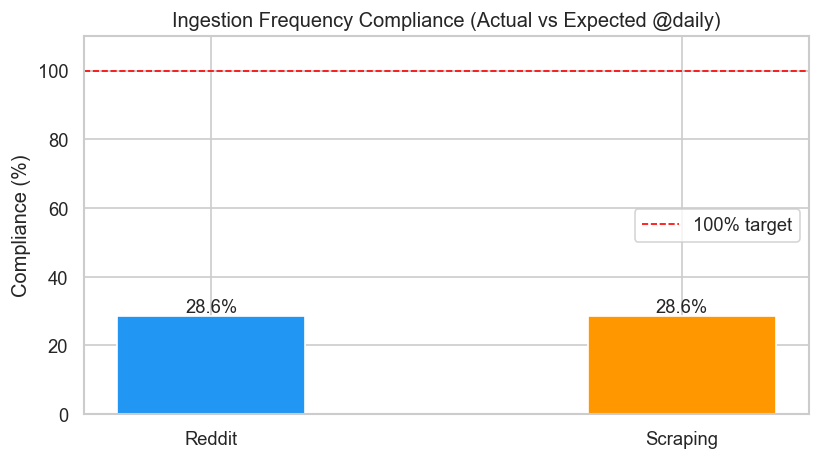

In [30]:
# ── Visual: Ingestion compliance ──────────────────────────────────────────
if not df_gov.empty and 'ingestion_compliance_reddit' in df_gov.columns:
    compliance = {
        'Reddit':   df_gov['ingestion_compliance_reddit'].iloc[0],
        'Scraping': df_gov['ingestion_compliance_scraping'].iloc[0]
    }
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(compliance.keys(), compliance.values(),
                  color=['#2196F3', '#FF9800'], edgecolor='white', width=0.4)
    ax.set_ylim(0, 110)
    ax.axhline(100, color='red', linestyle='--', linewidth=1, label='100% target')
    ax.set_ylabel('Compliance (%)')
    ax.set_title('Ingestion Frequency Compliance (Actual vs Expected @daily)')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig('ingestion_compliance.png', bbox_inches='tight')
    plt.show()

## 6. Storytelling Aggregations Preview

### 6.1 Sentiment Distribution

[SENTIMENT DISTRIBUTION] Loaded: sentiment_distribution_20260525_212434.parquet — 4 rows × 4 cols


,source,sentiment_label,count,pct
0,reddit,negative,25,23.15
1,reddit,neutral,21,19.44
2,reddit,positive,35,32.41
3,scraping,positive,27,25.00


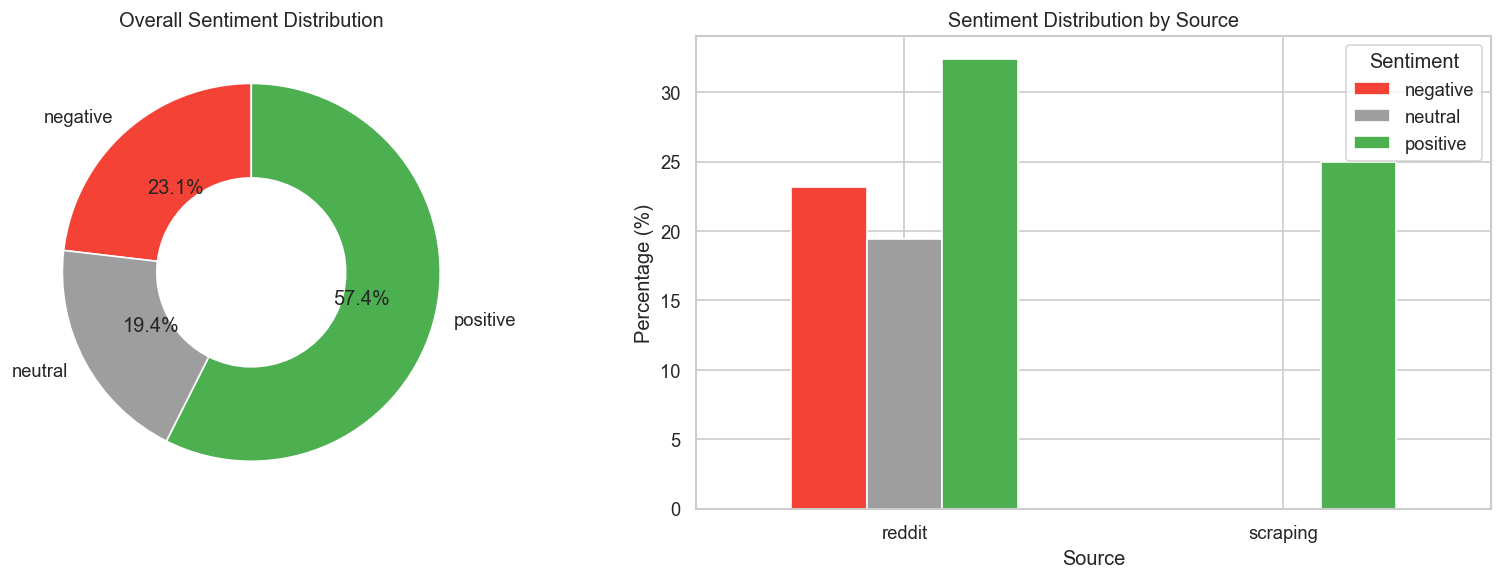

In [31]:
df_sent = load_latest('sentiment_distribution_*.parquet', 'SENTIMENT DISTRIBUTION')
if not df_sent.empty:
    display(df_sent)

    # ── Visual: Donut chart ───────────────────────────────────────────────
    overall = df_sent.groupby('sentiment_label')['count'].sum()
    colors  = {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall donut
    wedge_colors = [colors.get(l, 'blue') for l in overall.index]
    axes[0].pie(overall, labels=overall.index, autopct='%1.1f%%',
                colors=wedge_colors, startangle=90,
                wedgeprops=dict(width=0.5))
    axes[0].set_title('Overall Sentiment Distribution')

    # By source bar chart
    pivot = df_sent.pivot(index='source', columns='sentiment_label', values='pct').fillna(0)
    pivot.plot(kind='bar', ax=axes[1],
               color=[colors.get(c, 'gray') for c in pivot.columns],
               edgecolor='white', width=0.6)
    axes[1].set_title('Sentiment Distribution by Source')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(title='Sentiment')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('sentiment_distribution.png', bbox_inches='tight')
    plt.show()

### 6.2 Sentiment Trend Over Time

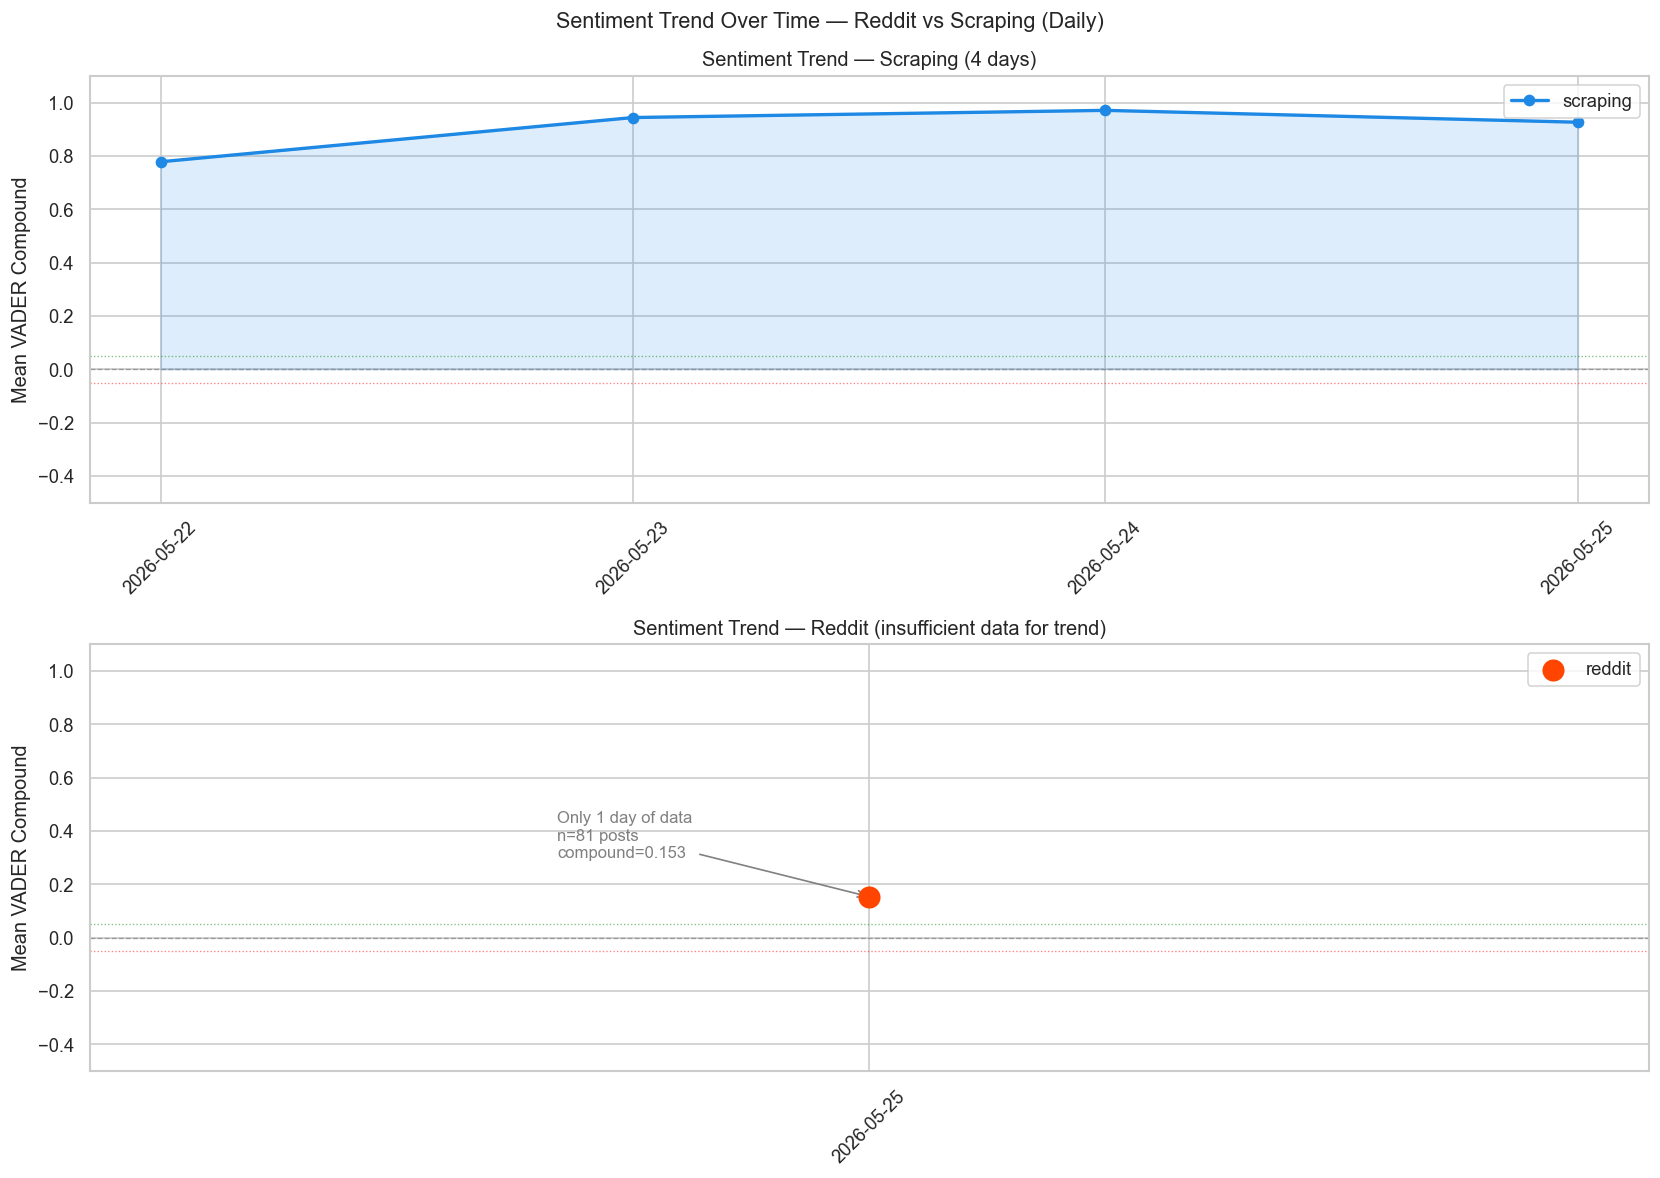


⚠️  Note: Reddit trend requires multiple ingestion cycles.
    Trigger the Bronze DAG daily to accumulate multi-day data.


In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = {"reddit": "#FF4500", "scraping": "#1E88E5"}

for ax, src in zip(axes, ["scraping", "reddit"]):
    grp = trend_daily[trend_daily["source"] == src].sort_values("date")

    if len(grp) > 1:
        ax.plot(grp["date"], grp["compound_mean"],
                marker="o", color=colors[src], linewidth=2, label=src)
        ax.fill_between(grp["date"], grp["compound_mean"],
                        alpha=0.15, color=colors[src])
    else:
        # Solo un punto — mostrar como scatter con anotación
        ax.scatter(grp["date"], grp["compound_mean"],
                   color=colors[src], s=150, zorder=5, label=src)
        ax.annotate(
            f"Only 1 day of data\nn={grp['n_records'].iloc[0]} posts\ncompound={grp['compound_mean'].iloc[0]:.3f}",
            xy=(grp["date"].iloc[0], grp["compound_mean"].iloc[0]),
            xytext=(0.3, 0.5), textcoords="axes fraction",
            fontsize=10, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray")
        )

    ax.axhline(0,     color="gray",  linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(0.05,  color="green", linestyle=":",  linewidth=0.8, alpha=0.5)
    ax.axhline(-0.05, color="red",   linestyle=":",  linewidth=0.8, alpha=0.5)
    ax.set_title(f"Sentiment Trend — {src.capitalize()} "
                 f"({'insufficient data for trend' if len(grp) <= 1 else f'{len(grp)} days'})")
    ax.set_ylabel("Mean VADER Compound")
    ax.set_ylim(-0.5, 1.1)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Sentiment Trend Over Time — Reddit vs Scraping (Daily)", fontsize=13)
plt.tight_layout()
plt.savefig("sentiment_trend_daily.png", bbox_inches="tight")
plt.show()

print("\n⚠️  Note: Reddit trend requires multiple ingestion cycles.")
print("    Trigger the Bronze DAG daily to accumulate multi-day data.")

### 6.3 Top Keywords

[TOP KEYWORDS] Loaded: top_keywords_20260525_212434.parquet — 30 rows × 2 cols


,keyword,frequency
0,week,444
1,match,436
2,real,169
3,madrid,164
4,run,148
5,good,134
6,game,120
7,player,115
8,goal,115
9,win,107


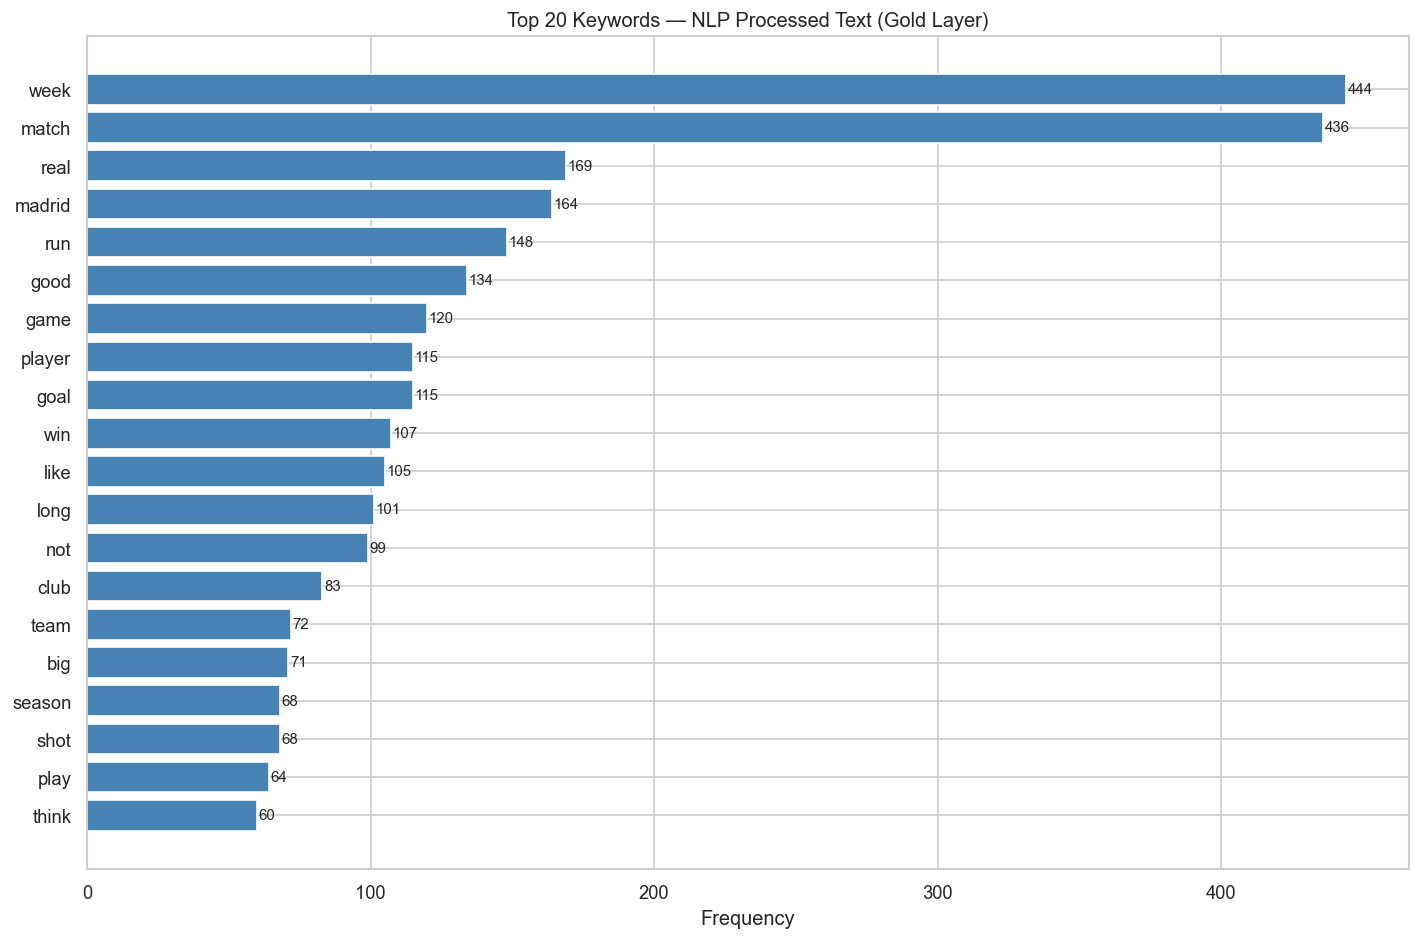

In [42]:
df_kw = load_latest('top_keywords_*.parquet', 'TOP KEYWORDS')
if not df_kw.empty:
    display(df_kw)

    fig, ax = plt.subplots(figsize=(12, 8))
    top20 = df_kw.nlargest(20, 'frequency')
    ax.barh(top20['keyword'][::-1], top20['frequency'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Frequency')
    ax.set_title('Top 20 Keywords — NLP Processed Text (Gold Layer)')
    for i, (kw, freq) in enumerate(zip(top20['keyword'][::-1], top20['frequency'][::-1])):
        ax.text(freq + 0.5, i, str(freq), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('top_keywords.png', bbox_inches='tight')
    plt.show()

### 6.4 Keyword Sentiment

[KEYWORD SENTIMENT] Loaded: keyword_sentiment_20260525_212434.parquet — 20 rows × 4 cols


,keyword,n_mentions,compound_mean,sentiment_mode
0,week,17,0.7543,positive
1,match,16,0.9516,positive
2,real,57,0.6405,positive
3,madrid,55,0.6526,positive
4,run,11,0.6900,positive
5,good,15,0.9124,positive
6,game,16,0.8367,positive
7,player,27,0.7399,positive
8,goal,16,0.7725,positive
9,win,20,0.8250,positive


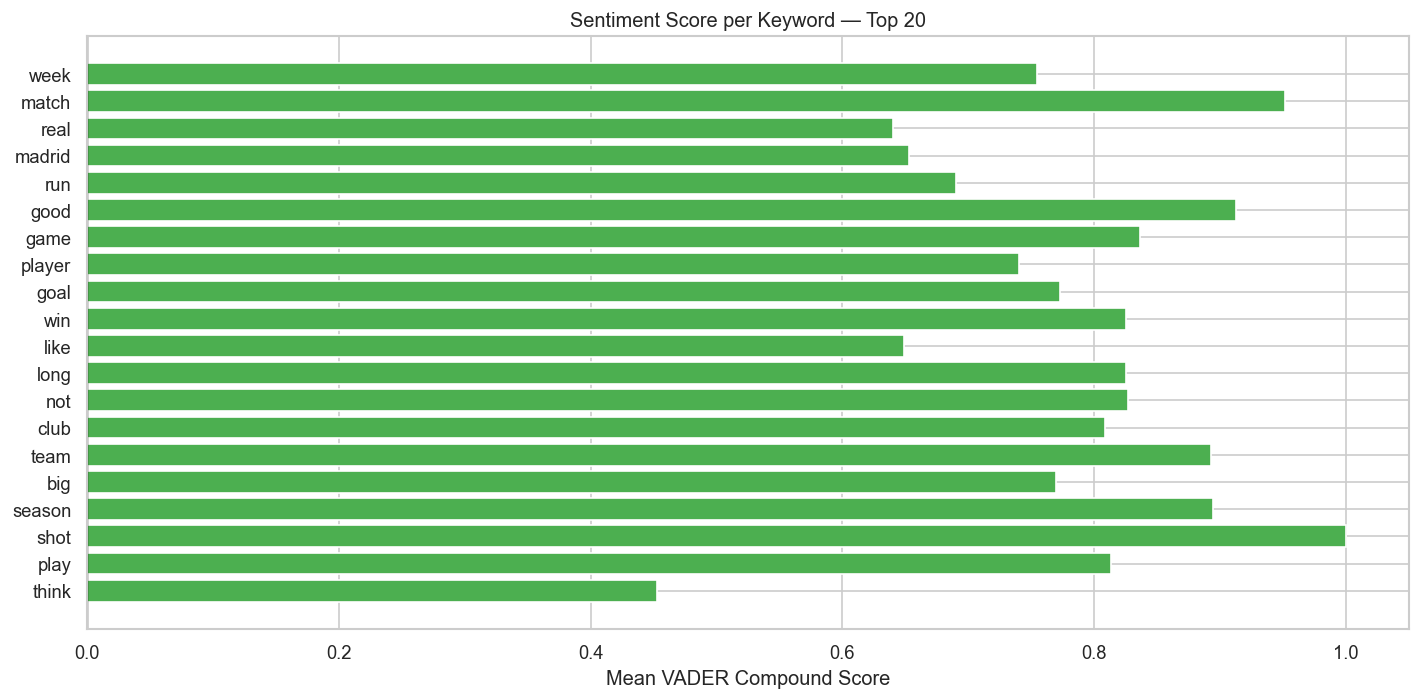

In [43]:
df_kws = load_latest('keyword_sentiment_*.parquet', 'KEYWORD SENTIMENT')
if not df_kws.empty:
    display(df_kws)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = df_kws['sentiment_mode'].map(
        {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
    )
    bars = ax.barh(df_kws['keyword'][::-1], df_kws['compound_mean'][::-1],
                   color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean VADER Compound Score')
    ax.set_title('Sentiment Score per Keyword — Top 20')
    plt.tight_layout()
    plt.savefig('keyword_sentiment.png', bbox_inches='tight')
    plt.show()

### 6.5 Source Comparison

[SOURCE COMPARISON] Loaded: source_comparison_20260525_212434.parquet — 2 rows × 8 cols


,source,n_records,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,avg_token_count
0,reddit,81,0.1533,0.5548,43.2099,25.9259,30.8642,111.9877
1,scraping,27,0.9003,0.1663,100.0000,0.0000,0.0000,149.7037


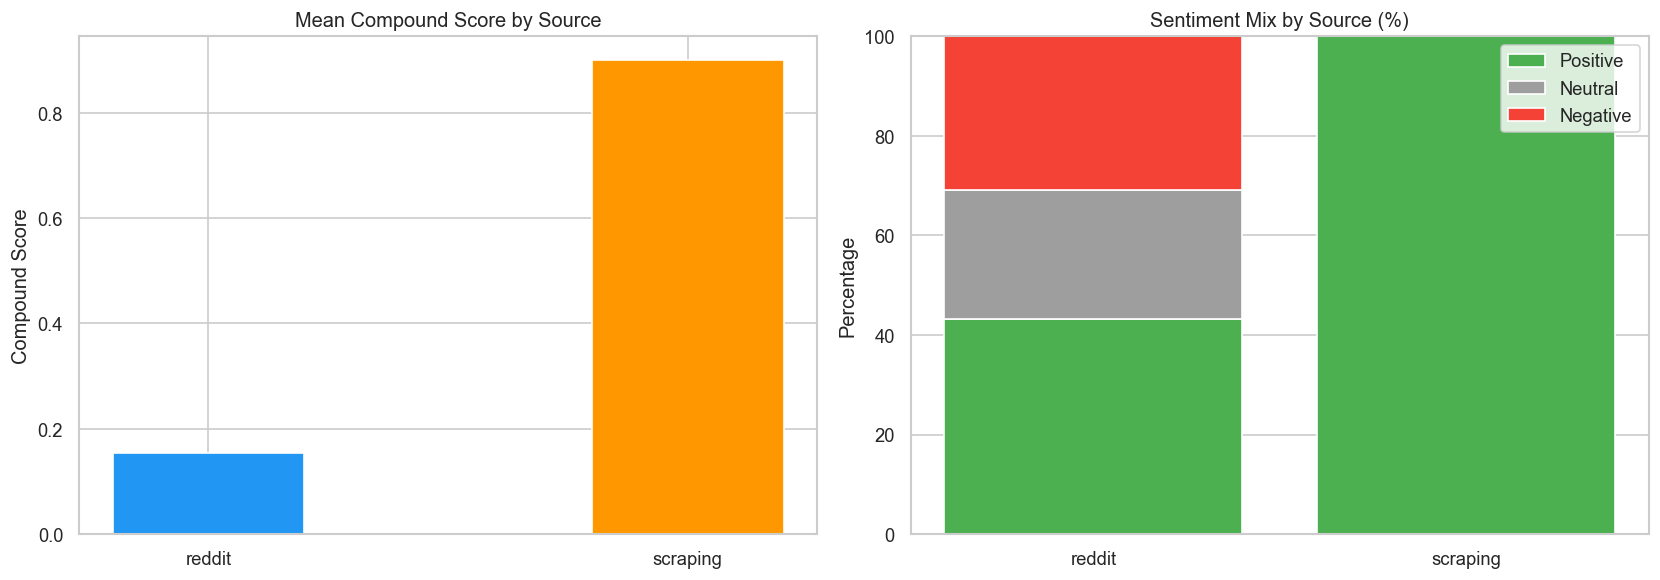

In [44]:
df_src = load_latest('source_comparison_*.parquet', 'SOURCE COMPARISON')
if not df_src.empty:
    display(df_src)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Compound mean by source
    axes[0].bar(df_src['source'], df_src['compound_mean'],
                color=['#2196F3', '#FF9800'], edgecolor='white', width=0.4)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_title('Mean Compound Score by Source')
    axes[0].set_ylabel('Compound Score')

    # Sentiment % stacked by source
    x = range(len(df_src))
    axes[1].bar(df_src['source'], df_src['pct_positive'],  label='Positive',  color='#4CAF50')
    axes[1].bar(df_src['source'], df_src['pct_neutral'],   label='Neutral',   color='#9E9E9E',
                bottom=df_src['pct_positive'])
    axes[1].bar(df_src['source'], df_src['pct_negative'],  label='Negative',  color='#F44336',
                bottom=df_src['pct_positive'] + df_src['pct_neutral'])
    axes[1].set_title('Sentiment Mix by Source (%)')
    axes[1].set_ylabel('Percentage')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('source_comparison.png', bbox_inches='tight')
    plt.show()

### 6.6 Aspect-Based Sentiment

[ASPECT SENTIMENT] Loaded: aspect_sentiment_20260525_212434.parquet — 23 rows × 9 cols


,aspect,source,n_mentions,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,sentiment_mode
0,mourinho,all,13,0.7888,0.4218,84.62,7.69,7.69,positive
1,mourinho,reddit,4,0.4186,0.6654,50.00,25.00,25.00,positive
2,mourinho,scraping,9,0.9534,0.0423,100.00,0.00,0.00,positive
3,mbappe,all,10,0.8132,0.3159,90.00,0.00,10.00,positive
4,mbappe,reddit,6,0.7098,0.3835,83.33,0.00,16.67,positive
5,mbappe,scraping,4,0.9683,0.0264,100.00,0.00,0.00,positive
6,vinicius,all,3,0.9651,0.0272,100.00,0.00,0.00,positive
7,vinicius,scraping,3,0.9651,0.0272,100.00,0.00,0.00,positive
8,carvajal,all,20,0.7394,0.5076,85.00,5.00,10.00,positive
9,carvajal,reddit,6,0.2980,0.7911,50.00,16.67,33.33,positive


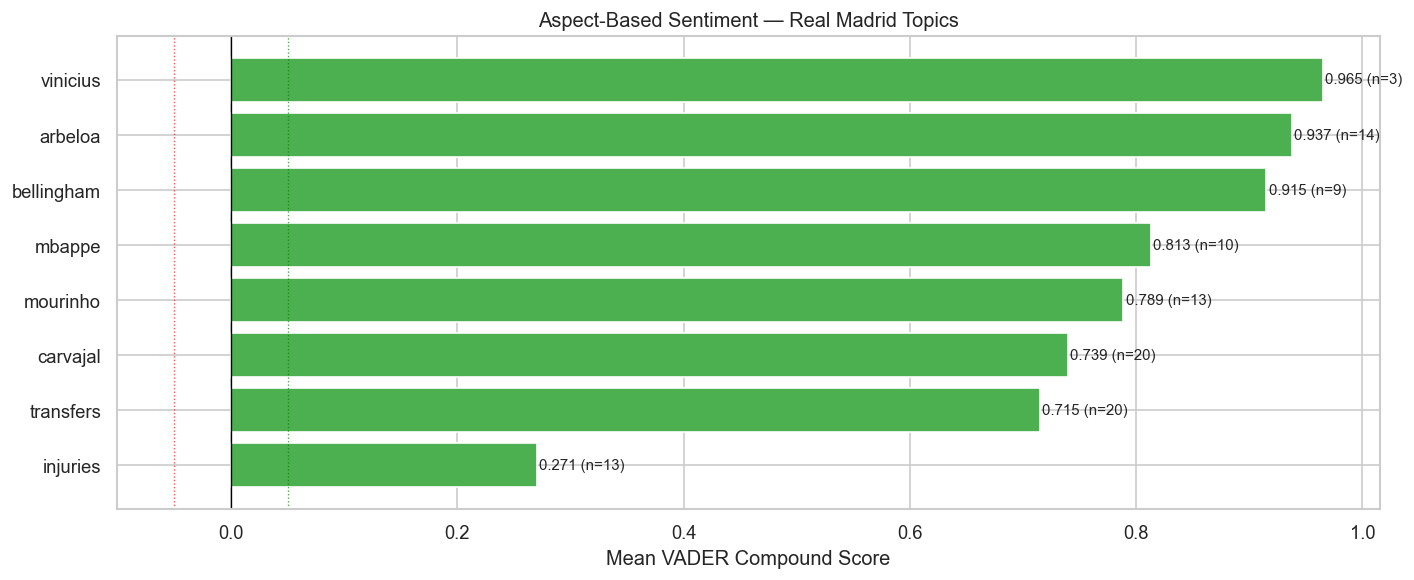

In [46]:
df_asp = load_latest('aspect_sentiment_*.parquet', 'ASPECT SENTIMENT')
if not df_asp.empty:
    display(df_asp)

    # ── Visual: Compound by aspect (global) ───────────────────────────────
    global_asp = df_asp[df_asp['source'] == 'all'].sort_values('compound_mean')

    if not global_asp.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        colors = ['#4CAF50' if v >= 0.05 else '#F44336' if v <= -0.05 else '#9E9E9E'
                  for v in global_asp['compound_mean']]
        ax.barh(global_asp['aspect'], global_asp['compound_mean'],
                color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.axvline(0.05,  color='green', linestyle=':', linewidth=0.8, alpha=0.7)
        ax.axvline(-0.05, color='red',   linestyle=':', linewidth=0.8, alpha=0.7)
        ax.set_xlabel('Mean VADER Compound Score')
        ax.set_title('Aspect-Based Sentiment — Real Madrid Topics')

        for i, (_, row) in enumerate(global_asp.iterrows()):
            ax.text(row['compound_mean'] + 0.002, i,
                    f"{row['compound_mean']:.3f} (n={row['n_mentions']})",
                    va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig('aspect_sentiment.png', bbox_inches='tight')
        plt.show()

## 7. Storytelling Summary Metadata

In [47]:
df_story = load_latest('storytelling_summary_*.parquet', 'STORYTELLING SUMMARY')
if not df_story.empty:
    display(df_story.T.rename(columns={0: 'value'}))

[STORYTELLING SUMMARY] Loaded: storytelling_summary_20260525_212434.parquet — 1 rows × 9 cols


,value
pipeline_run_ts,20260525_212434
total_records,108
sources,"['scraping', 'reddit']"
weeks_covered,2
top_keyword,week
overall_sentiment,positive
overall_compound,0.34
aggregations_saved,"['sentiment_distribution', 'sentiment_trend', ..."
aspects_analyzed,"['mourinho', 'mbappe', 'vinicius', 'carvajal',..."


## 8. Dashboard Narrative

Based on the Gold layer aggregations above, the storytelling dashboard will communicate the following narrative to the functional user:

> **"Real Madrid fan sentiment on Reddit vs sports press coverage — who is more optimistic?"**
>
> The dashboard answers:
> 1. Is public opinion on Real Madrid positive, negative, or neutral — and has that changed over time?
> 2. Which players and topics (transfers, injuries) generate the strongest reactions?
> 3. Do fans on Reddit express sentiment differently from journalists in sports media?
> 4. What are the most discussed topics in Real Madrid coverage, and are they positive or negative?

Each Gold aggregation maps to a specific chart in the Workshop 4 dashboard.

In [39]:
mapping = [
    {'aggregation': 'sentiment_distribution', 'chart': 'Donut chart + KPI cards', 'user_story': 'US-01: User wants overall sentiment summary'},
    {'aggregation': 'sentiment_trend',        'chart': 'Line chart (compound over time)', 'user_story': 'US-02: User wants temporal opinion shifts'},
    {'aggregation': 'top_keywords',           'chart': 'Bar chart / Word cloud', 'user_story': 'US-03: User wants to know what topics dominate'},
    {'aggregation': 'keyword_sentiment',      'chart': 'Horizontal bar (color=sentiment)', 'user_story': 'US-03: User wants keyword-level sentiment'},
    {'aggregation': 'source_comparison',      'chart': 'Side-by-side bar + stacked bar', 'user_story': 'US-04: User wants Reddit vs press comparison'},
    {'aggregation': 'volume_trend',           'chart': 'Area chart', 'user_story': 'US-05: User wants activity peak detection'},
    {'aggregation': 'aspect_sentiment',       'chart': 'Horizontal bar by player/topic', 'user_story': 'US-06: User wants player-level sentiment'},
]

display(pd.DataFrame(mapping))

,aggregation,chart,user_story
0,sentiment_distribution,Donut chart + KPI cards,US-01: User wants overall sentiment summary
1,sentiment_trend,Line chart (compound over time),US-02: User wants temporal opinion shifts
2,top_keywords,Bar chart / Word cloud,US-03: User wants to know what topics dominate
3,keyword_sentiment,Horizontal bar (color=sentiment),US-03: User wants keyword-level sentiment
4,source_comparison,Side-by-side bar + stacked bar,US-04: User wants Reddit vs press comparison
5,volume_trend,Area chart,US-05: User wants activity peak detection
6,aspect_sentiment,Horizontal bar by player/topic,US-06: User wants player-level sentiment
